# Weekly Average Forecasting of Citywide  Rat Sightings

We ask if forecasting at a citywide level at a weekly basis can smooth out the issue of there being many outliers at the daily level. 
Since we are inevitably interested in the daily number of rat sightings, we attempt to forecast the weekly average number of rat sightings reported. One reason for doing would be that it could inform city planners of how many workers they need at hand during certain weeks to handly rat sightings reports.

In this notebook, we experiment to see if some of the models we had considered before can predict the weekly average well.

Since we only making some preliminary tests, we use data from 2020-01-01 to 2026-02-28 for this notebook.

# Import Packages

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression

from prophet import Prophet
from pandas.tseries.holiday import USFederalHolidayCalendar
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
from prophet.plot import add_changepoints_to_plot
import itertools

import logging
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)
logging.getLogger('prophet').setLevel(logging.ERROR)
logging.getLogger('pytorch_lightning').setLevel(logging.ERROR)

import xgboost as xgb
from xgboost import plot_importance

# Time Series Split

In [ ]:
# Create time series split for weekly data (2 week test set = ~14 days equivalent)
tscv_weekly = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=39, test_size=2)
tscv = tscv_weekly

# Importing the Data

In [ ]:
# this is the time series split we will work with
tscv = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=26, test_size=14)


# we import the data and clean it for future use
rs = pd.read_csv('../../scr/data/cleaned_rat_sightings_data/all_cleaned_rat_sightings.csv')
rs['created_date'] = pd.to_datetime(rs['created_date']) 
# mark cutoff dates, and also rename columns
rs = rs[rs['created_date']<'2026-03-01']
rs = rs[rs['created_date']>='2020-01-01']
rs = rs.groupby([rs['created_date'].dt.date]).size().reset_index(name='count')

In [ ]:
## We find the missing row and add it in.
## There's probably a better way to find in the missing dates and update it. This is a sort of hacky solution.

date_range = pd.date_range(start=rs['created_date'].min(), end=rs['created_date'].max(), freq='D')
complete_dates_df = pd.DataFrame(date_range, columns=['created_date'])
rs = pd.merge(complete_dates_df, rs, on='created_date', how='left')
rs['count'] = rs['count'].fillna(0).astype(int)
rs = rs.sort_values(by='created_date').reset_index(drop=True)


In [ ]:
# Rename columns for Prophet model
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)

# Ensure ds is datetime
rs['ds'] = pd.to_datetime(rs['ds'])

# Aggregate data to weekly average
rs_weekly = rs.set_index('ds').resample('W')['y'].mean().reset_index()
rs_weekly.columns = ['ds', 'y']

# Create dataframe explaining week ranges
week_explanation = rs_weekly[['ds']].copy()
week_explanation['week_start'] = week_explanation['ds'] - pd.Timedelta(days=6)
week_explanation['week_end'] = week_explanation['ds']
week_explanation = week_explanation[['week_start', 'week_end', 'ds']]

In [ ]:
rs_weekly

,ds,y
0,2020-01-05,8.400000
1,2020-01-12,8.428571
2,2020-01-19,9.857143
3,2020-01-26,11.428571
4,2020-02-02,8.857143
...,...,...
317,2026-02-01,7.428571
318,2026-02-08,6.857143
319,2026-02-15,6.857143
320,2026-02-22,10.714286


In [ ]:
week_explanation

,week_start,week_end,ds
0,2019-12-30,2020-01-05,2020-01-05
1,2020-01-06,2020-01-12,2020-01-12
2,2020-01-13,2020-01-19,2020-01-19
3,2020-01-20,2020-01-26,2020-01-26
4,2020-01-27,2020-02-02,2020-02-02
...,...,...,...
317,2026-01-26,2026-02-01,2026-02-01
318,2026-02-02,2026-02-08,2026-02-08
319,2026-02-09,2026-02-15,2026-02-15
320,2026-02-16,2026-02-22,2026-02-22


# Baseline Seasonal Average Model

In [ ]:
def seasonal_average_forecast_weekly(data, target_dates, years_back=4, week_window=1):
    
    df = data.copy()
    
    # Ensure datetime
    df["ds"] = pd.to_datetime(df["ds"])
    
    # Extract seasonal features
    df["week"] = df["ds"].dt.isocalendar().week.astype(int)
    df["year"] = df["ds"].dt.year

    forecasts = []

    for target_date in target_dates:
        
        target_week = target_date.isocalendar().week
        target_year = target_date.year
        
        mask = (
            (df["year"] >= target_year - years_back) &
            (df["year"] < target_year) &
            (np.abs(df["week"] - target_week) <= week_window)
        )
        
        forecasts.append(df.loc[mask, "y"].mean())

    return pd.Series(forecasts, index=target_dates)

In [ ]:
results = []

rs_weekly["ds"] = pd.to_datetime(rs_weekly["ds"])

for i, (train_index, test_index) in enumerate(tscv.split(rs_weekly)):
    
    train = rs_weekly.iloc[train_index].copy()
    test = rs_weekly.iloc[test_index].copy()
    
    # Target weeks we want to forecast
    target_dates = test["ds"]
    # Weekly seasonal forecast
    y_pred = seasonal_average_forecast_weekly(data=train, target_dates=target_dates, years_back=4, week_window=1)

    y_true = test["y"].values
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    results.append({"fold": i,"rmse": rmse,"mape": mape})

baseline_results_df = pd.DataFrame(results)

# Add mean row
baseline_results_df.loc["mean"] = ["mean",baseline_results_df["rmse"].mean(),baseline_results_df["mape"].mean()]

In [ ]:
baseline_results_df

,fold,rmse,mape
0,0,3.383341,0.182250
1,1,1.351938,0.071802
2,2,1.458637,0.073988
3,3,1.242323,0.073055
4,4,2.496838,0.136591
5,5,0.629097,0.038302
6,6,2.290066,0.198495
7,7,2.276286,0.237722
8,8,3.420442,0.298611
9,9,2.537837,0.194824


Notice that the RMSE of the baseline model drops drastically in comparison to the situation with daily forecasting. This is a good sign that taking weekly averages "smooths" away the outliers that occur.

# Prophet Model

In [ ]:
# Create a date range covering 2020 through end of 2025
date_range = pd.date_range(start="2020-01-01", end="2026-02-28")


# Generate US federal holidays
calendar = USFederalHolidayCalendar()
holidays = calendar.holidays(start=date_range.min(), end=date_range.max())
federal_holidays = pd.DataFrame({'holiday': 'federal_us','ds': pd.to_datetime(holidays),'lower_window': 0,'upper_window': 1,})

holidays = federal_holidays

In [ ]:
# Disable all logging
logging.disable(logging.CRITICAL)

In [ ]:
results = []

for i, (train_index, test_index) in enumerate(tscv_weekly.split(rs_weekly)):
    train = rs_weekly.iloc[train_index]
    test = rs_weekly.iloc[test_index]
    
    model = Prophet(holidays=holidays)
    model.add_country_holidays(country_name='US')
    model.fit(train)
    
    # Calculate number of weeks to forecast
    num_forecast_weeks = len(test)
    future = model.make_future_dataframe(periods=num_forecast_weeks, freq='W')
    forecast = model.predict(future)
    
    # Obtain predicted values and compare against the actuals.
    y_pred = forecast['yhat'][-num_forecast_weeks:].values
    y_true = test['y'].values
    
    # Metrics
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    # Append results
    results.append({'fold': i, 'rmse': rmse, 'mape': mape})

# Re-enable logging after Prophet modeling
logging.disable(logging.NOTSET)

# Convert results to a datafrane
prophet_results_df = pd.DataFrame(results)
prophet_results_df.loc['mean'] = ['mean',  prophet_results_df['rmse'].mean(), prophet_results_df['mape'].mean()]

In [ ]:
prophet_results_df

,fold,rmse,mape
0,0,1.375481,0.077492
1,1,1.431313,0.074863
2,2,4.594882,0.231876
3,3,2.595788,0.119157
4,4,1.375479,0.073719
5,5,2.220681,0.151738
6,6,1.276951,0.115697
7,7,0.371660,0.038864
8,8,1.065496,0.105221
9,9,0.192875,0.013516


# SARIMA Model

We can see if SARIMA makes better predictions. The main issue with SARIMA and using it for daily data was the number of lags that would be needed to take into account for yearly seasonality. At a weekly level, this issue is lifted.

In [ ]:
from pmdarima import auto_arima

In [ ]:
def fourier_terms(df, period, n_terms):
    t = np.arange(1, len(df) + 1)
    fourier_df = pd.DataFrame()
    
    for i in range(1, n_terms + 1):
        fourier_df[f'sin_{i}'] = np.sin(2 * np.pi * i * t / period)
        fourier_df[f'cos_{i}'] = np.cos(2 * np.pi * i * t / period)
    
    return fourier_df

# Number of Fourier terms and period 
n_terms = 30
period = 26 

fourier_train = fourier_terms(rs, period, n_terms)
# Name it exog since it will serve as exogenous features for SARIMAX. This is the X.
exog = fourier_train

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

results = []

# Ensure proper order
rs_weekly = rs_weekly.sort_values("ds").reset_index(drop=True)

# Loop through each fold
for i, (train_index, test_index) in enumerate(tscv.split(rs_weekly)):
    
    train = rs_weekly.iloc[train_index]
    test = rs_weekly.iloc[test_index]

    exog_train = exog.iloc[train_index]
    exog_test = exog.iloc[test_index]

    model_auto = auto_arima(train['y'], exog=exog_train, trace=True, stepwise=True, suppress_warnings=True, n_jobs=-1)

    orders = model_auto.order
    seasonal_orders = model_auto.seasonal_order

    # Fit SARIMAX
    model_sarimax = SARIMAX(train['y'], order=orders, exog=exog_train,
                            seasonal_order=seasonal_orders, 
                            enforce_stationarity=False, enforce_invertibility=False)

    model_fit = model_sarimax.fit(disp=False)

    # Forecast for test period
    y_pred = model_fit.predict(start=len(train), end=len(train) + len(test) - 1, exog=exog_test, dynamic=False)

    y_true = test['y'].values

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)

    results.append({'fold': i, 'rmse': rmse, 'mape': mape})

sarima_results_df = pd.DataFrame(results)
sarima_results_df.loc['mean'] = ['mean',  sarima_results_df['rmse'].mean(), sarima_results_df['mape'].mean()]

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=1207.401, Time=0.25 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1244.374, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1214.966, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1202.511, Time=0.04 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1242.448, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1203.423, Time=0.06 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1203.451, Time=0.04 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=1205.423, Time=0.10 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=1200.778, Time=0.03 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=1201.726, Time=0.03 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=1201.749, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=1213.109, Time=0.02 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=1203.726, Time=0.06 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0]          
Total fit time: 0.710 seconds
Performing stepwise se

In [ ]:
sarima_results_df

,fold,rmse,mape
0,0,2.444213,0.107874
1,1,1.164557,0.059573
2,2,3.630827,0.174286
3,3,7.741896,0.466482
4,4,0.887009,0.056531
5,5,2.424798,0.174391
6,6,5.862989,0.487588
7,7,2.462213,0.241784
8,8,2.770269,0.264198
9,9,1.829242,0.135550


In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [ ]:
results = []

for i, (train_index, test_index) in enumerate(tscv.split(rs_weekly)):
    
    train = rs_weekly.iloc[train_index]
    test = rs_weekly.iloc[test_index]
    
    holt_winters = ExponentialSmoothing(train['y'], seasonal='add', seasonal_periods=26).fit(optimized=True)
    y_pred = holt_winters.forecast(len(test))
    y_true = test['y'].values

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    results.append({'fold': i, 'rmse': rmse, 'mape': mape})

hw_results_df = pd.DataFrame(results)
hw_results_df.loc['mean'] = ['mean',  hw_results_df['rmse'].mean(), hw_results_df['mape'].mean()]

In [ ]:
hw_results_df

,fold,rmse,mape
0,0,3.569258,0.199284
1,1,1.861912,0.094436
2,2,1.239802,0.062722
3,3,4.264535,0.204804
4,4,4.844423,0.313064
5,5,0.540853,0.035838
6,6,2.593982,0.224092
7,7,1.444062,0.125497
8,8,1.078908,0.091533
9,9,0.743743,0.041964


# XGBoost Model

The XGBoost model requires a bit more preparatory work. Our current dataframe rs_weekly is quite bare and we should features for use.

## Adding Features to XGBoost

In [ ]:
def create_weekly_features(df, forecast_horizon_weeks=2):
    df = df.copy()
    df["ds"] = pd.to_datetime(df["ds"])
    df = df.sort_values("ds")

    df["year"] = df["ds"].dt.year
    df["quarter"] = df["ds"].dt.quarter
    df["month"] = df["ds"].dt.month
    df["weekofyear"] = df["ds"].dt.isocalendar().week.astype(int)


    df["weekofyear_sin"] = np.sin(2 * np.pi * df["weekofyear"] / 52)
    df["weekofyear_cos"] = np.cos(2 * np.pi * df["weekofyear"] / 52)
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)



    shift = forecast_horizon_weeks
    df["lag1"] = df["y"].shift(shift + 1)
    df["lag2"] = df["y"].shift(shift + 2)
    df["lag3"] = df["y"].shift(shift + 3)
    df["lag4"] = df["y"].shift(shift + 4)
    df["lag8"] = df["y"].shift(shift + 8)
    df["lag12"] = df["y"].shift(shift + 12)
    df["lag26"] = df["y"].shift(shift + 26)
    df["lag52"] = df["y"].shift(shift + 52)
    df["lag104"] = df["y"].shift(shift + 104)



    df["ma4"] = df["y"].shift(shift).rolling(4).mean()
    df["ma8"] = df["y"].shift(shift).rolling(8).mean()
    df["ma12"] = df["y"].shift(shift).rolling(12).mean()
    df["ma26"] = df["y"].shift(shift).rolling(26).mean()
    df["ma52"] = df["y"].shift(shift).rolling(52).mean()

    return df

In [ ]:
## Add weekly average weather data

import requests
import pandas as pd

lat, lon = 40.7831, -73.9712
start = "2020-01-01"
end   = "2026-02-28"

url = ("https://archive-api.open-meteo.com/v1/archive"
    f"?latitude={lat}&longitude={lon}"
    f"&start_date={start}&end_date={end}"
    "&daily=temperature_2m_mean"
    "&timezone=America/New_York")

response = requests.get(url)
data = response.json()



wd = pd.DataFrame(data["daily"])
wd["date"] = pd.to_datetime(wd["time"])
wd = wd.set_index("date")
wd = wd.drop(columns=["time"])

# Convert daily weather to weekly averages
wd_weekly = (wd.resample("W").mean().rename(columns={"temperature_2m_mean": "weekly_avg_temp"}))

def add_weather_data_weekly(df, wd_weekly):
    df = df.copy()
    wd_weekly = wd_weekly.copy()
    df["ds"] = pd.to_datetime(df["ds"])
    wd_weekly.index = pd.to_datetime(wd_weekly.index)
    df = df.merge(wd_weekly,left_on="ds",right_index=True,how="left")

    return df

In [ ]:
from pandas.tseries.holiday import USFederalHolidayCalendar
import pandas as pd

def add_weekly_federal_holidays(df, custom_holidays=None):
    df = df.copy()
    df["ds"] = pd.to_datetime(df["ds"])
    
    cal = USFederalHolidayCalendar()
    holidays = cal.holidays(start=df["ds"].min(),end=df["ds"].max())

    if custom_holidays:
        for d in custom_holidays:
            if len(d) == 5:  # MM-DD format
                years = df["ds"].dt.year.unique()
                for y in years:
                    holidays = pd.concat([
                        holidays,
                        pd.to_datetime([f"{y}-{d}"])
                    ])
            else:  # YYYY-MM-DD format
                holidays = pd.concat([
                    holidays,
                    pd.to_datetime([d])
                ])

    holidays = pd.to_datetime(holidays).drop_duplicates()

    # Determine week range (Monday–Sunday since resample('W') ends on Sunday)
    df["week_start"] = df["ds"] - pd.Timedelta(days=6)
    df["week_end"] = df["ds"]

    # Check if any holiday falls inside each week
    def week_has_holiday(row):
        return int(((holidays >= row["week_start"]) &(holidays <= row["week_end"])).any())

    df["has_federal_holiday"] = df.apply(week_has_holiday, axis=1)

    return df.drop(columns=["week_start", "week_end"])

In [ ]:
def add_weekly_weather_lags(df, forecast_horizon_weeks=2):
    df = df.copy()
    df = df.sort_values("ds")
    df["ds"] = pd.to_datetime(df["ds"])
    df = df.set_index("ds")

    shift = forecast_horizon_weeks

    # Weekly temperature lags
    df["weekly_avg_temp_lag1"] = df["weekly_avg_temp"].shift(shift + 1)
    df["weekly_avg_temp_lag2"] = df["weekly_avg_temp"].shift(shift + 2)
    df["weekly_avg_temp_lag4"] = df["weekly_avg_temp"].shift(shift + 4)
    df["weekly_avg_temp_lag8"] = df["weekly_avg_temp"].shift(shift + 8)
    df["weekly_avg_temp_lag12"] = df["weekly_avg_temp"].shift(shift + 12)

    # Yearly seasonal lags (very important for weather)
    df["weekly_avg_temp_lag52"] = df["weekly_avg_temp"].shift(52)
    df["weekly_avg_temp_lag104"] = df["weekly_avg_temp"].shift(104)

    return df.reset_index()

In [ ]:
rs_weekly = rs_weekly.sort_values("ds").reset_index(drop=True)

rs_weekly = create_weekly_features(rs_weekly, forecast_horizon_weeks=14)
rs_weekly = add_weather_data_weekly(rs_weekly, wd_weekly)
rs_weekly = add_weekly_weather_lags(rs_weekly, forecast_horizon_weeks=14)

rs_weekly = add_weekly_federal_holidays(rs_weekly)

In [ ]:
rs_weekly.columns

Index(['ds', 'y', 'year', 'quarter', 'month', 'weekofyear', 'weekofyear_sin',
       'weekofyear_cos', 'month_sin', 'month_cos', 'lag1', 'lag2', 'lag3',
       'lag4', 'lag8', 'lag12', 'lag26', 'lag52', 'lag104', 'ma4', 'ma8',
       'ma12', 'ma26', 'ma52', 'weekly_avg_temp', 'weekly_avg_temp_lag1',
       'weekly_avg_temp_lag2', 'weekly_avg_temp_lag4', 'weekly_avg_temp_lag8',
       'weekly_avg_temp_lag12', 'weekly_avg_temp_lag52',
       'weekly_avg_temp_lag104', 'has_federal_holiday'],
      dtype='object')

In [ ]:
FEATURES = ['year', 'quarter', 'month', 'weekofyear', 'weekofyear_sin',
       'weekofyear_cos', 'month_sin', 'month_cos', 'lag1', 'lag2', 'lag3',
       'lag4', 'lag8', 'lag12', 'lag26', 'lag52', 'lag104', 'ma4', 'ma8',
       'ma12', 'ma26', 'ma52', 'weekly_avg_temp', 'weekly_avg_temp_lag1',
       'weekly_avg_temp_lag2', 'weekly_avg_temp_lag4', 'weekly_avg_temp_lag8',
       'weekly_avg_temp_lag12', 'weekly_avg_temp_lag52', 'weekly_avg_temp_lag104', 'has_federal_holiday']


## Add default parameters for XGBoost

In [ ]:
params = {'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'booster': 'gbtree', 
          'base_score': 0.5, 'n_estimators': 100, 
          'min_child_weight': 7, 'learning_rate': 0.01, 
          'max_depth': 8}

## uncomment to use GPU
params.update({"tree_method": "hist", "device": "cuda"})


## Results for XGBoost Model

In [ ]:
TARGET = "y"

# Initialize model
reg = xgb.XGBRegressor(**params)

results = []
for i, (train_index, test_index) in enumerate(tscv.split(rs_weekly)):
    
    train = rs_weekly.iloc[train_index]
    test = rs_weekly.iloc[test_index]
    
    # Fit model
    reg.fit(train[FEATURES], train[TARGET])
    
    # Predict
    y_pred = reg.predict(test[FEATURES])
    y_true = test[TARGET].values
    
    # Metrics
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    results.append({"fold": i, "rmse": rmse, "mape": mape})
    
    print(results)

# Convert to DataFrame
xgb_results_df = pd.DataFrame(results)

# Add mean row
mean_rmse = xgb_results_df["rmse"].mean()
mean_mape = xgb_results_df["mape"].mean()

xgb_results_df.loc["mean"] = ["mean", mean_rmse, mean_mape]

[{'fold': 0, 'rmse': 5.091007548623839, 'mape': 0.2764666616631467}]
[{'fold': 0, 'rmse': 5.091007548623839, 'mape': 0.2764666616631467}, {'fold': 1, 'rmse': 6.433499686320551, 'mape': 0.34506105284654465}]
[{'fold': 0, 'rmse': 5.091007548623839, 'mape': 0.2764666616631467}, {'fold': 1, 'rmse': 6.433499686320551, 'mape': 0.34506105284654465}, {'fold': 2, 'rmse': 8.217286771518179, 'mape': 0.41685111929700136}]
[{'fold': 0, 'rmse': 5.091007548623839, 'mape': 0.2764666616631467}, {'fold': 1, 'rmse': 6.433499686320551, 'mape': 0.34506105284654465}, {'fold': 2, 'rmse': 8.217286771518179, 'mape': 0.41685111929700136}, {'fold': 3, 'rmse': 5.273040788555887, 'mape': 0.29861655162654355}]
[{'fold': 0, 'rmse': 5.091007548623839, 'mape': 0.2764666616631467}, {'fold': 1, 'rmse': 6.433499686320551, 'mape': 0.34506105284654465}, {'fold': 2, 'rmse': 8.217286771518179, 'mape': 0.41685111929700136}, {'fold': 3, 'rmse': 5.273040788555887, 'mape': 0.29861655162654355}, {'fold': 4, 'rmse': 6.455279553525

In [ ]:
xgb_results_df

,fold,rmse,mape
0,0,5.091008,0.276467
1,1,6.433500,0.345061
2,2,8.217287,0.416851
3,3,5.273041,0.298617
4,4,6.455280,0.407083
5,5,5.288635,0.383639
6,6,2.810558,0.251387
7,7,2.282132,0.237499
8,8,3.350774,0.299040
9,9,4.993844,0.390531


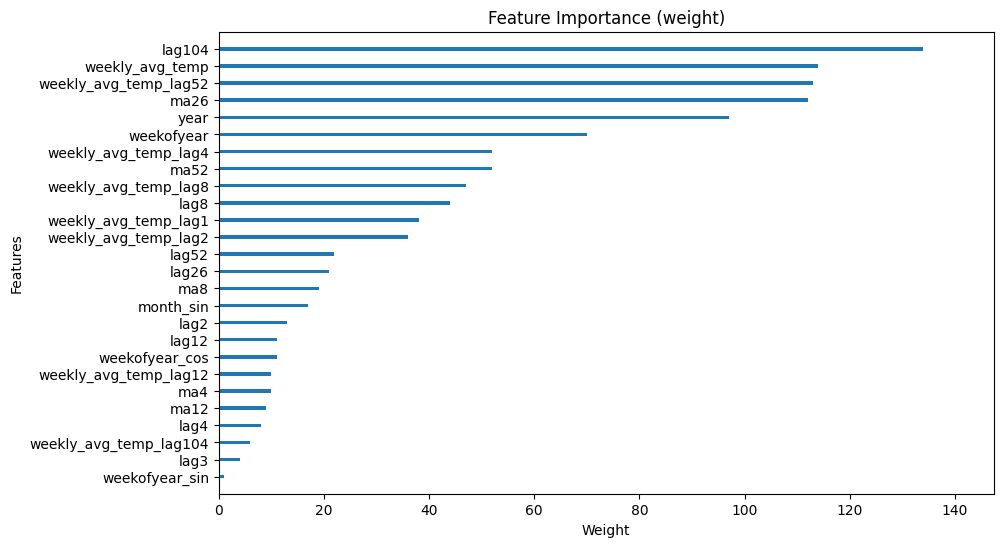

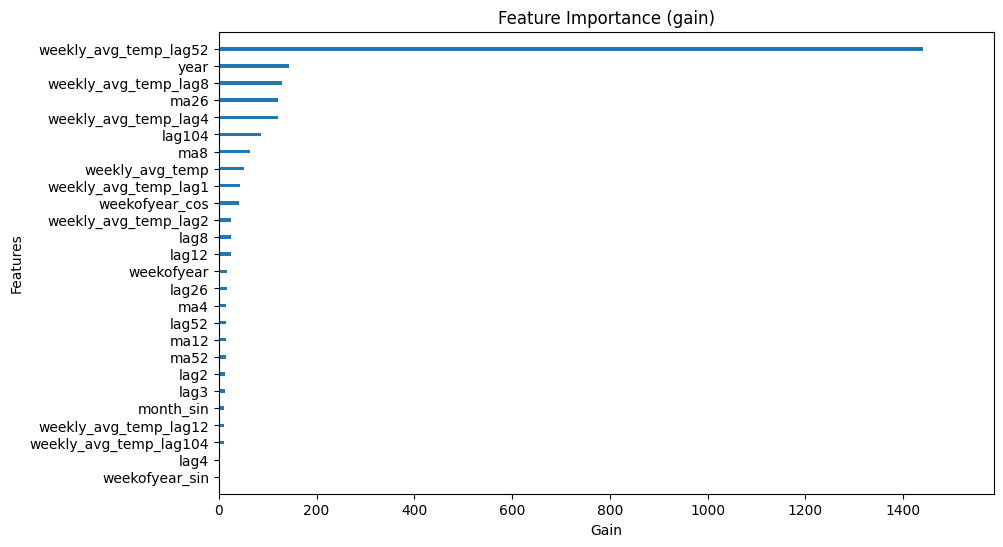

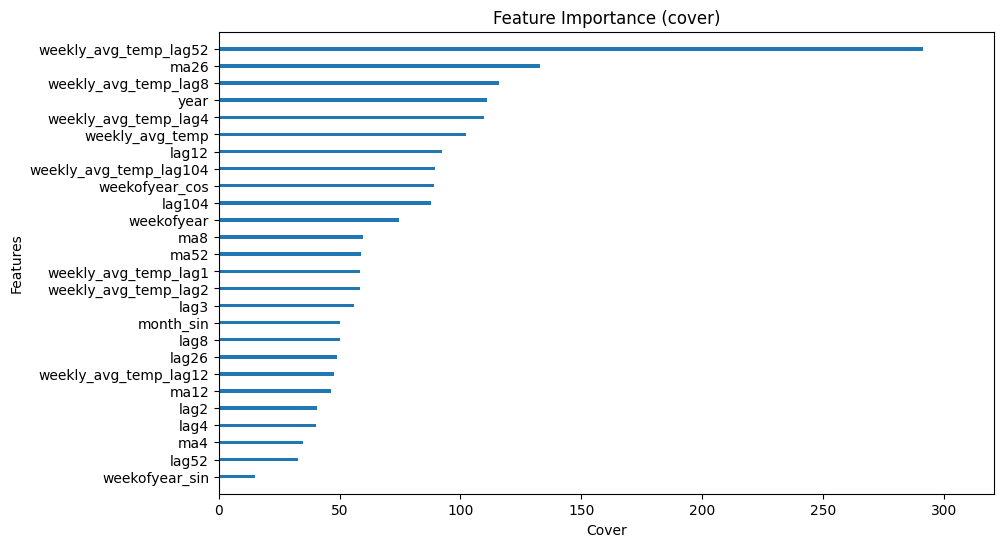

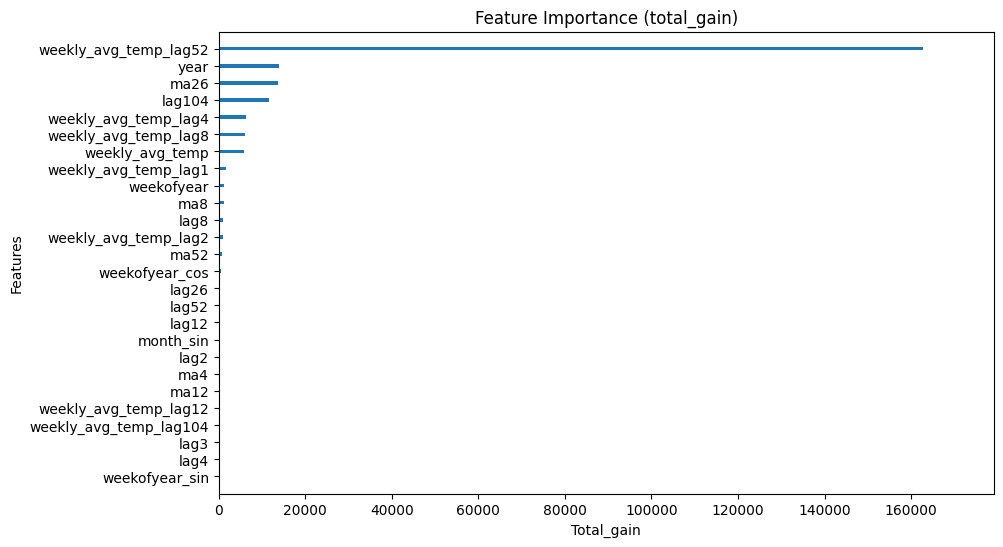

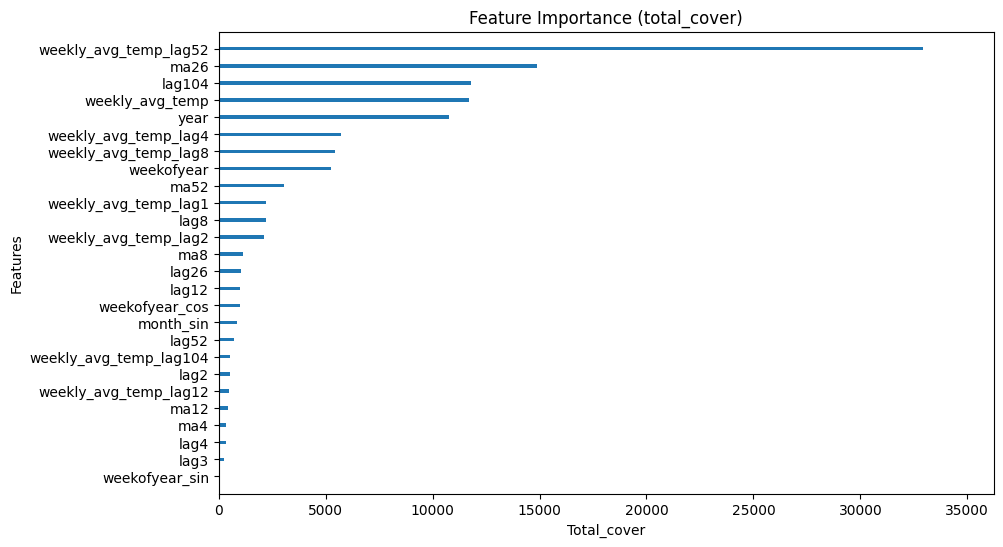

In [ ]:
model = reg.fit(train[FEATURES], train[TARGET])
importance_types = ['weight', 'gain', 'cover', 'total_gain', 'total_cover']
for importance_type in importance_types:
    fig, ax = plt.subplots(figsize=(10, 6))
    xgb.plot_importance(model, ax=ax, importance_type=importance_type, grid=False, show_values=False)
    plt.xlabel(f'{importance_type}'.capitalize())
    plt.title(f'Feature Importance ({importance_type})')
    plt.show()

# Results Table

In [ ]:
models = {'baseline': baseline_results_df, 'prophet': prophet_results_df, 'sarima': sarima_results_df, 'hw': hw_results_df, 'xgb': xgb_results_df,}

all_results = []
for model_name, df in models.items():
    df['model'] = model_name
    all_results.append(df)

final_results_df = pd.concat(all_results, ignore_index=True)
final_table = final_results_df.pivot(index='fold', columns='model', values=['rmse', 'mape'])
final_table.index = final_table.index.where(final_table.index != '-', 'mean')

final_table

rmse                                               mape            \
model  baseline        hw   prophet    sarima        xgb  baseline        hw   
fold                                                                           
0      3.383341  3.569258  1.375481  2.444213   5.091008  0.182250  0.199284   
1      1.351938  1.861912  1.431313  1.164557   6.433500  0.071802  0.094436   
2      1.458637  1.239802  4.594882  3.630827   8.217287  0.073988  0.062722   
3      1.242323  4.264535  2.595788  7.741896   5.273041  0.073055  0.204804   
4      2.496838  4.844423  1.375479  0.887009   6.455280  0.136591  0.313064   
5      0.629097  0.540853  2.220681  2.424798   5.288635  0.038302  0.035838   
6      2.290066  2.593982  1.276951  5.862989   2.810558  0.198495  0.224092   
7      2.276286  1.444062  0.371660  2.462213   2.282132  0.237722  0.125497   
8      3.420442  1.078908  1.065496  2.770269   3.350774  0.298611  0.091533   
9      2.537837  0.743743  0.192875  1.829242   4.993844  0.194824  0.041964   
10     3.587918  3.720774  4.927479  3.944580   7.298520  0.225639  0.187372   
11     3.627936  4.394155  1.166793  2.464462   2.523196  0.349476  0.425792   
12     3.827524  2.461796  1.926776  4.211964   4.294910  0.303549  0.188071   
13     2.534135  2.216642  2.215451  2.479417   4.488339  0.160836  0.118787   
14     2.729386  4.591717  6.262421  7.908153   8.900890  0.111700  0.246746   
15     2.981769  2.331937  1.501415  3.930754   3.785292  0.194853  0.159975   
16     3.547110  1.861128  0.634632  2.285308   3.932600  0.232807  0.121942   
17     2.159624  1.956324  2.324994  2.103651   6.323060  0.116523  0.080676   
18     6.267877  3.103968  3.772340  2.455197   4.848691  0.406398  0.210097   
19     2.076110  5.095955  2.623982  4.221823   7.267706  0.102391  0.258399   
20     1.214519  5.382335  5.898147  4.371712  10.458944  0.053793  0.238070   
21     2.675223  4.045600  2.120683  6.753823   6.232894  0.119889  0.186023   
22     6.996805  5.036430  2.532447  5.028168   3.202601  0.439046  0.309470   
23     7.458217  2.250480  3.174268  5.267428   4.802762  0.444116  0.133816   
24     6.654464  1.594699  2.577732  4.420454   4.325491  0.405221  0.081530   
25     4.014289  3.840209  2.675430  3.654059   6.980465  0.196193  0.144201   
26     3.917662  3.015554  3.203010  2.024696   6.903074  0.184309  0.145116   
27     6.035245  3.807358  2.177534  5.634649   3.244793  0.398929  0.230175   
28     7.242817  3.674924  2.656622  0.688085   1.307065  0.572073  0.286087   
29     6.791753  2.947237  2.101044  3.661401   1.951762  0.583857  0.209587   
30     8.283683  4.508048  3.695797  4.943465   0.905191  0.867258  0.471328   
31     5.709683  0.631262  1.651678  2.850046   0.707683  0.620228  0.068943   
32     5.814772  1.200008  1.224583  1.950490   0.939867  0.768927  0.155083   
33     5.109799  1.312255  0.566768  0.753159   1.051795  0.711173  0.163763   
34     6.477066  1.262560  1.512721  2.419120   1.197058  0.868289  0.164840   
35     4.361475  1.985843  1.643472  5.465877   3.695293  0.423781  0.165954   
36     6.275656  1.943162  1.962190  0.873856   2.060015  0.755741  0.192418   
37     7.620131  1.057263  1.854723  1.544132   0.768310  1.110243  0.145282   
38     5.985740  2.403919  2.005822  1.852448   2.134728  0.648358  0.199097   
mean   4.181159  2.713206  2.284399  3.368728   4.275104  0.355929  0.181586   

                                     
model   prophet    sarima       xgb  
fold                                 
0      0.077492  0.107874  0.276467  
1      0.074863  0.059573  0.345061  
2      0.231876  0.174286  0.416851  
3      0.119157  0.466482  0.298617  
4      0.073719  0.056531  0.407083  
5      0.151738  0.174391  0.383639  
6      0.115697  0.487588  0.251387  
7      0.038864  0.241784  0.237499  
8      0.105221  0.264198  0.299040  
9      0.013516  0.135550  0.390531  
10     0.227892  0.226219  0.415726  
11     0.110736  0.186762  0.220270  


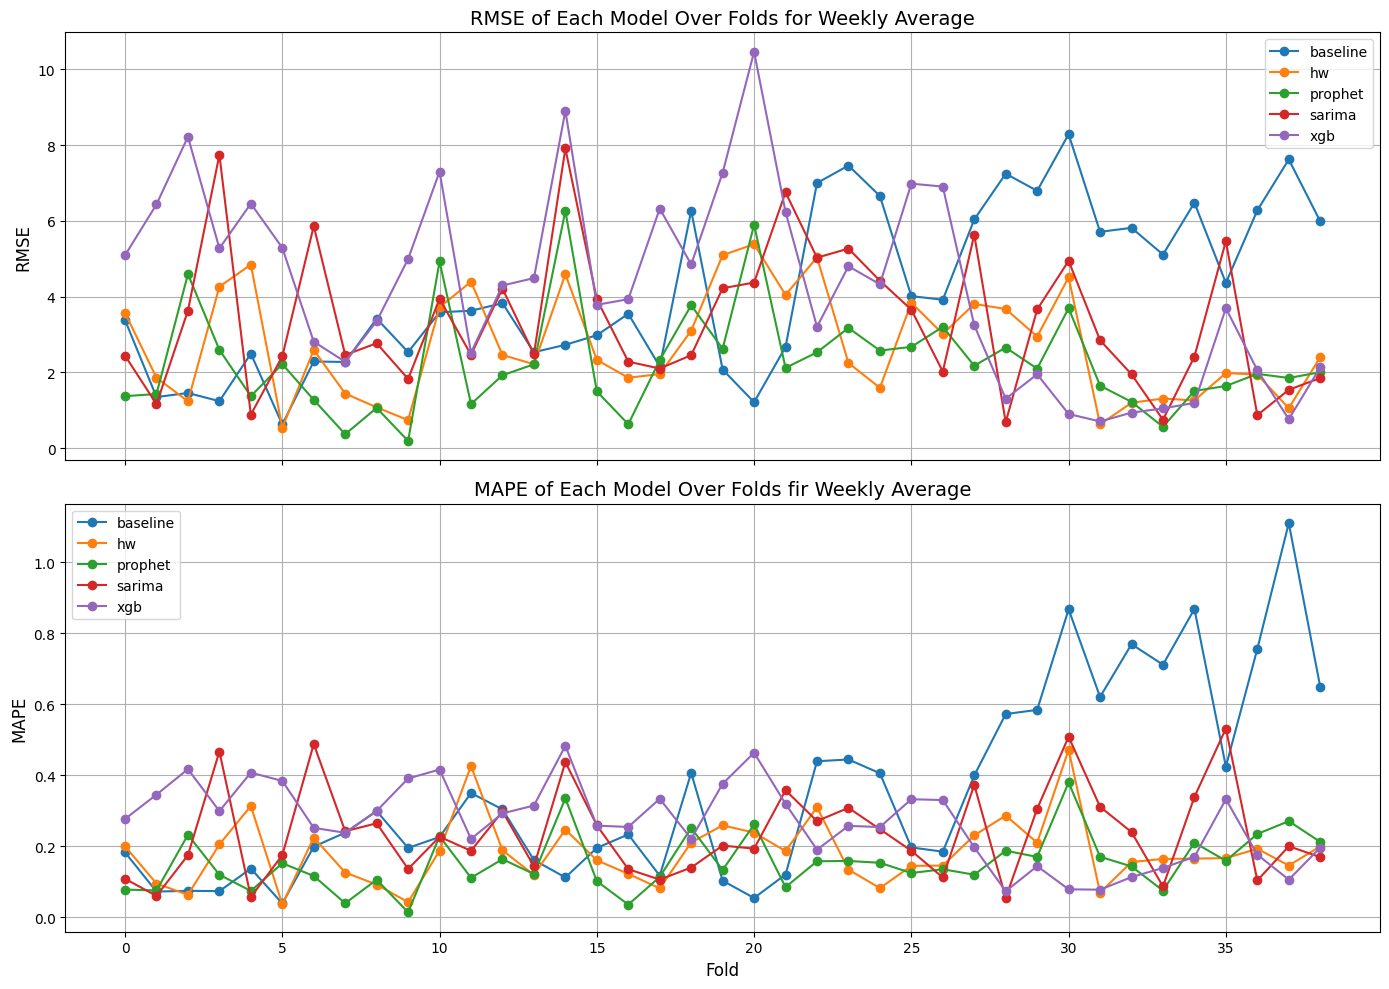

In [ ]:
import matplotlib.pyplot as plt

# Make a copy and drop 'mean' row if present
plot_table = final_table.drop(index='mean', errors='ignore')
# Use fold numbers as x-axis
x = plot_table.index

# Create subplots: 2 rows, 1 column
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# RMSE
for model in plot_table['rmse'].columns:
    axes[0].plot(x, plot_table['rmse'][model], marker='o', label=model)
axes[0].set_title('RMSE of Each Model Over Folds for Weekly Average', fontsize=14)
axes[0].set_ylabel('RMSE', fontsize=12)
axes[0].legend()
axes[0].grid(True)

# MAPE
for model in plot_table['mape'].columns:
    axes[1].plot(x, plot_table['mape'][model], marker='o', label=model)
axes[1].set_title('MAPE of Each Model Over Folds fir Weekly Average', fontsize=14)
axes[1].set_ylabel('MAPE', fontsize=12)
axes[1].set_xlabel('Fold', fontsize=12)
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()